# LightGBM (30 features) — per `type` models (ALLOW/BLOCK)

Dataset folder format (one or more roots):
```
<root>/
  booking/
    allow/*.json
    block/*.json
  captcha/
    allow/*.json
    block/*.json
  detail/
    allow/*.json
    block/*.json
```

- Target: `block` → 1, `allow` → 0
- Train: one LightGBM model per `type` directory (booking/captcha/detail/...)
- Save: `services/ai/train/model_joblib/lightgbm_30_v3/type=<TYPE>/model.joblib`


## 1) Args / inputs


In [123]:
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

args = SimpleNamespace(
    RUN_VERSION='lightgbm_30_v3',
    # One or more dataset roots. Supports globs like `.../data_*_gt_v2`.
    DATA_ROOTS=[],
    MODEL_SAVE_DIR=Path('../model_joblib') / 'lightgbm_30_v3',
    RANDOM_STATE=42,
    TEST_SIZE=0.2,
    MAX_MISSING_RATE=0.2,
    SAVE_MODEL=True,
    # Minimum samples / positives to train a type-specific model
    MIN_SAMPLES_PER_TYPE=200,
    MIN_POS_PER_TYPE=20,
    # LightGBM params
    N_ESTIMATORS=5000,
    LEARNING_RATE=0.03,
    NUM_LEAVES=63,
    MIN_CHILD_SAMPLES=20,
    MIN_DATA_IN_BIN=1,
    MIN_SPLIT_GAIN=0.0,
    SUBSAMPLE=0.9,
    COLSAMPLE_BYTREE=0.9,
    REG_ALPHA=0.0,
    REG_LAMBDA=0.0,
    EARLY_STOPPING_ROUNDS=150,
)
args

namespace(RUN_VERSION='lightgbm_30_v3',
          DATA_ROOTS=[],
          MODEL_SAVE_DIR=WindowsPath('../model_joblib/lightgbm_30_v3'),
          RANDOM_STATE=42,
          TEST_SIZE=0.2,
          MAX_MISSING_RATE=0.2,
          SAVE_MODEL=True,
          MIN_SAMPLES_PER_TYPE=200,
          MIN_POS_PER_TYPE=20,
          N_ESTIMATORS=5000,
          LEARNING_RATE=0.03,
          NUM_LEAVES=63,
          MIN_CHILD_SAMPLES=20,
          MIN_DATA_IN_BIN=1,
          MIN_SPLIT_GAIN=0.0,
          SUBSAMPLE=0.9,
          COLSAMPLE_BYTREE=0.9,
          REG_ALPHA=0.0,
          REG_LAMBDA=0.0,
          EARLY_STOPPING_ROUNDS=150)

In [124]:
def _expand_inputs(inputs: list[str]) -> list[Path]:
    out: list[Path] = []
    for raw in inputs:
        raw = str(raw).strip().strip('"').strip("'")
        if not raw:
            continue
        if any(ch in raw for ch in ['*', '?', '[']):
            out.extend(sorted(Path().glob(raw)))
        else:
            out.append(Path(raw))
    # de-dupe while preserving order
    seen = set()
    uniq: list[Path] = []
    for p in out:
        rp = str(p.resolve()) if p.exists() else str(p)
        if rp in seen:
            continue
        seen.add(rp)
        uniq.append(p)
    return uniq

# Default roots (edit as needed)
default_roots = [
    r'C:/Users/SSAFY/Desktop/ws/free/develop-ai/S14P31A203/services/ai/data/train_data_0518/data_0515_1400_gt_v2',
    r'C:/Users/SSAFY/Desktop/ws/free/develop-ai/S14P31A203/services/ai/data/train_data_0518/data_tickle_0515_human_v2',
]
# Non-interactive: just use the list above.
# To add/remove datasets, edit `default_roots` (you can add as many as you want).
args.DATA_ROOTS = list(default_roots)

roots = _expand_inputs(args.DATA_ROOTS)
print('n_roots =', len(roots))
for p in roots[:10]:
    print(' -', p)
assert len(roots) > 0, 'No dataset roots found'

n_roots = 2
 - C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\train_data_0518\data_0515_1400_gt_v2
 - C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\train_data_0518\data_tickle_0515_human_v2


## 2) Feature list (30)


In [125]:
FEATURES = [
  'reclick_rate',
  'misclick_rate',
  'double_click_rate',
  'mouse_overshoot_flag',
  'mousemove_event_rate',
  'pre_click_scroll_flag',
  'time_to_first_click_ms',
  'mouse_acceleration_mean',
  'mouse_speed_change_mean',
  'pre_click_hover_time_ms',
  'mouse_stop_segment_count',
  'mouse_avg_speed_px_per_ms',
  'mouse_hover_dwell_time_ms',
  'mouse_max_speed_px_per_ms',
  'mouse_path_curvature_mean',
  'pre_click_mousemove_count',
  'click_position_repeat_rate',
  'mouse_direction_change_count',
  'mouse_path_straightness_score',
  'edge_or_fixed_point_visit_rate',
  'mouse_total_travel_distance_px',
  'click_sequence_consistency_score',
  'immediate_post_render_click_rate',
  'pre_click_path_300ms_straightness',
  'pre_click_path_500ms_straightness',
  'click_offset_from_element_center_px',
  'time_from_element_visible_to_click_ms',
  'pre_click_path_300ms_total_distance_px',
  'pre_click_path_500ms_total_distance_px',
  'time_from_element_clickable_to_click_ms',
]
len(FEATURES)

30

## 3) Load dataset roots → DataFrame


In [126]:
def _safe_lower(x) -> str:
    return str(x).strip().lower()

def _infer_type_and_label(path: Path):
    # Expect .../<type>/<allow|block>/<file>.json
    try:
        label_dir = _safe_lower(path.parent.name)
        type_dir = str(path.parent.parent.name).strip()
        if label_dir not in ('allow', 'block'):
            return None, None
        if not type_dir:
            return None, None
        return type_dir, label_dir.upper()
    except Exception:
        return None, None

def _load_trial_json(path: Path) -> dict:
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_from_roots(roots: list[Path]) -> pd.DataFrame:
    rows = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.rglob('*.json'):
            type_dir, label = _infer_type_and_label(p)
            if type_dir is None:
                continue
            obj = _load_trial_json(p)
            feats = None
            if isinstance(obj, dict):
                # Most datasets store features under `metrics`.
                feats = obj.get('features')
                if feats is None:
                    feats = obj.get('metrics')
                if feats is None:
                    # fallback: treat top-level numeric keys as features
                    feats = {k: v for k, v in obj.items() if k not in ('trialID', 'trialId', 'type', 'label', 'summary', 'metrics', 'features')}
            if feats is None:
                feats = {}
            rows.append({
                'source_root': str(root),
                'source_file': str(p),
                'trialID': (obj.get('trialID') if isinstance(obj, dict) else None) or (obj.get('trialId') if isinstance(obj, dict) else None),
                'type': type_dir,
                'label': label,
                **(feats or {}),
            })
    return pd.DataFrame(rows)

df = load_from_roots(roots)
print('df.shape =', df.shape)
df[['type', 'label', 'source_file']].head()

df.shape = (1354, 39)


,type,label,source_file
0,booking,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P...
1,booking,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P...
2,booking,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P...
3,booking,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P...
4,booking,ALLOW,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P...


In [127]:
df['label'].value_counts(dropna=False), df['type'].value_counts(dropna=False).head(20)

(label
 ALLOW    680
 BLOCK    674
 Name: count, dtype: int64,
 type
 detail     486
 captcha    467
 booking    401
 Name: count, dtype: int64)

## 4) Train per type + save


In [128]:
# If not installed: pip install lightgbm
import lightgbm as lgb

def build_xy(sub: pd.DataFrame):
    """Build fixed 30-feature matrix for serving compatibility.

    - Always returns X with columns exactly == FEATURES (order preserved)
    - No feature-dropping (missing-rate/constant) to avoid training feature-count mismatch
    """
    sub = sub.copy()
    for c in FEATURES:
        if c not in sub.columns:
            sub[c] = np.nan

    y = (sub['label'].astype(str).str.upper() == 'BLOCK').astype(int)
    X = sub[FEATURES].apply(pd.to_numeric, errors='coerce')

    med = X.median(numeric_only=True)
    # If median can't be computed (all-NaN), fill with 0.
    X = X.fillna(med).fillna(0)
    return X, y, med

def train_one_type(type_name: str, sub: pd.DataFrame) -> dict:
    X, y, med = build_xy(sub)

    n = len(y)
    pos = int(y.sum())
    if n < args.MIN_SAMPLES_PER_TYPE or pos < args.MIN_POS_PER_TYPE or pos == 0 or pos == n:
        return {
            'type': type_name,
            'skipped': True,
            'n': n,
            'pos': pos,
            'reason': f'too_small_or_single_class (n={n}, pos={pos})',
        }

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=args.TEST_SIZE,
        random_state=args.RANDOM_STATE,
        stratify=y,
    )

    clf = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=args.N_ESTIMATORS,
        learning_rate=args.LEARNING_RATE,
        num_leaves=args.NUM_LEAVES,
        min_child_samples=args.MIN_CHILD_SAMPLES,
        min_data_in_bin=args.MIN_DATA_IN_BIN,
        min_split_gain=args.MIN_SPLIT_GAIN,
        subsample=args.SUBSAMPLE,
        colsample_bytree=args.COLSAMPLE_BYTREE,
        reg_alpha=args.REG_ALPHA,
        reg_lambda=args.REG_LAMBDA,
        random_state=args.RANDOM_STATE,
        n_jobs=-1,
        force_col_wise=True,
        verbose=-1,
    )

    start = time.time()
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=['binary_logloss', 'auc'],
        callbacks=[lgb.early_stopping(args.EARLY_STOPPING_ROUNDS, verbose=False)],
    )
    elapsed = time.time() - start

    proba_valid = clf.predict_proba(X_valid)[:, 1]
    pred_valid = (proba_valid >= 0.5).astype(int)

    auc = roc_auc_score(y_valid, proba_valid)
    ap = average_precision_score(y_valid, proba_valid)
    ll = log_loss(y_valid, proba_valid)
    acc = accuracy_score(y_valid, pred_valid)
    p, r, f1, _ = precision_recall_fscore_support(y_valid, pred_valid, average='binary', zero_division=0)

    return {
        'type': type_name,
        'skipped': False,
        'n': n,
        'pos': pos,
        'pos_rate': float(pos / n),
        'n_features_used': int(X.shape[1]),
        'best_iteration': int(getattr(clf, 'best_iteration_', 0) or 0),
        'elapsed_sec': float(elapsed),
        'AUC': float(auc),
        'AP': float(ap),
        'LogLoss': float(ll),
        'Acc': float(acc),
        'Precision': float(p),
        'Recall': float(r),
        'F1': float(f1),
        'model': clf,
        'features_used': list(X.columns),
        'median_imputer': med,
        'valid_pred': pd.DataFrame({'type': type_name, 'y_true': y_valid.values, 'y_pred': pred_valid, 'proba': proba_valid}),
        'cm': confusion_matrix(y_valid, pred_valid),
        'report': classification_report(y_valid, pred_valid, digits=4),
    }

df = df.copy()
df['type'] = df['type'].astype(str).fillna('')
types = sorted([t for t in df['type'].unique().tolist() if t])
print('types:', types)

results = []
for t in types:
    sub = df[df['type'] == t]
    res = train_one_type(t, sub)
    results.append(res)
    if res.get('skipped'):
        print(f"[SKIP] type={t} n={res['n']} pos={res['pos']} reason={res['reason']}")
    else:
        print(f"[OK] type={t} n={res['n']} pos={res['pos']} AUC={res['AUC']:.4f} AP={res['AP']:.4f} F1={res['F1']:.4f}")

# Pooled (all types together)
pooled = train_one_type('POOLED', df)
if pooled.get('skipped'):
    print(f"[SKIP] pooled n={pooled['n']} pos={pooled['pos']} reason={pooled['reason']}")
else:
    print(f"[OK] pooled n={pooled['n']} pos={pooled['pos']} AUC={pooled['AUC']:.4f} AP={pooled['AP']:.4f} F1={pooled['F1']:.4f}")

summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'valid_pred', 'cm', 'report', 'median_imputer', 'features_used']} for r in results])
summary.sort_values(['skipped', 'n'], ascending=[True, False])

types: ['booking', 'captcha', 'detail']
[OK] type=booking n=401 pos=220 AUC=1.0000 AP=1.0000 F1=0.7040
[OK] type=captcha n=467 pos=226 AUC=1.0000 AP=1.0000 F1=0.9783
[OK] type=detail n=486 pos=228 AUC=0.9996 AP=0.9995 F1=0.9787
[OK] pooled n=1354 pos=674 AUC=1.0000 AP=1.0000 F1=0.9888


,type,skipped,n,pos,pos_rate,n_features_used,best_iteration,elapsed_sec,AUC,AP,LogLoss,Acc,Precision,Recall,F1
2,detail,False,486,228,0.469136,30,144,0.265229,0.999582,0.999537,0.052766,0.979592,0.958333,1.0,0.978723
1,captcha,False,467,226,0.483940,30,79,0.261120,1.000000,1.000000,0.076565,0.978723,0.957447,1.0,0.978261
0,booking,False,401,220,0.548628,30,2,0.170986,1.000000,1.000000,0.633352,0.543210,0.543210,1.0,0.704000


In [129]:
if args.SAVE_MODEL:
    args.MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

    def _json_safe(obj):
        if isinstance(obj, Path):
            return str(obj)
        if isinstance(obj, (list, tuple)):
            return [_json_safe(x) for x in obj]
        if isinstance(obj, dict):
            return {str(k): _json_safe(v) for k, v in obj.items()}
        return obj

    args_dump = _json_safe(vars(args))

    joblib.dump(
        {'args': args_dump, 'dataset_roots': [str(p) for p in roots], 'features_all': FEATURES},
        args.MODEL_SAVE_DIR / 'run_meta.joblib',
    )

    all_valid = []
    for r in results:
        t = r['type']
        outdir = args.MODEL_SAVE_DIR / f'type={t}'
        outdir.mkdir(parents=True, exist_ok=True)

        if r.get('skipped'):
            (outdir / 'SKIPPED.txt').write_text(r.get('reason', 'skipped'), encoding='utf-8')
            continue

        # For Linux-serving compatibility, store the model object only.
        joblib.dump(r['model'], outdir / 'model.joblib')

        # Also write meta.json (compatible with services/ai/test/data_loader.py)
        meta = {
            'feature_names': list(r['features_used']),
            'n_features': int(len(r['features_used'])),
            'label_mapping': {'human': 0, 'macro': 1},
            'type': t,
            'run_version': args.RUN_VERSION,
            'args': args_dump,
        }
        (outdir / 'meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
        (outdir / 'input_features.json').write_text(
            json.dumps(list(r['features_used']), ensure_ascii=False, indent=2) + '\n',
            encoding='utf-8',
        )

        pd.DataFrame({'cm': r['cm'].reshape(-1)}).to_csv(outdir / 'confusion_matrix_flat.csv', index=False)
        (outdir / 'classification_report.txt').write_text(r['report'], encoding='utf-8')
        r['valid_pred'].to_csv(outdir / 'valid_predictions.csv', index=False)
        all_valid.append(r['valid_pred'])

        imp = pd.DataFrame({
            'feature': r['features_used'],
            'importance_gain': r['model'].booster_.feature_importance(importance_type='gain'),
            'importance_split': r['model'].booster_.feature_importance(importance_type='split'),
        }).sort_values('importance_gain', ascending=False)
        imp.to_csv(outdir / 'feature_importance.csv', index=False)

    # Save pooled model in the root of MODEL_SAVE_DIR (single model for all types)
    if 'pooled' in globals() and isinstance(pooled, dict) and not pooled.get('skipped'):
        # For Linux-serving compatibility, store the model object only.
        joblib.dump(pooled['model'], args.MODEL_SAVE_DIR / 'model.joblib')

        pooled_meta = {
            'feature_names': list(pooled['features_used']),
            'n_features': int(len(pooled['features_used'])),
            'label_mapping': {'human': 0, 'macro': 1},
            'type': 'POOLED',
            'run_version': args.RUN_VERSION,
            'args': args_dump,
        }
        (args.MODEL_SAVE_DIR / 'meta.json').write_text(
            json.dumps(pooled_meta, ensure_ascii=False, indent=2) + '\n',
            encoding='utf-8',
        )
        (args.MODEL_SAVE_DIR / 'input_features.json').write_text(
            json.dumps(list(pooled['features_used']), ensure_ascii=False, indent=2) + '\n',
            encoding='utf-8',
        )
        pooled['valid_pred'].to_csv(args.MODEL_SAVE_DIR / 'pooled_valid_predictions.csv', index=False)
        pooled_imp = pd.DataFrame({
            'feature': pooled['features_used'],
            'importance_gain': pooled['model'].booster_.feature_importance(importance_type='gain'),
            'importance_split': pooled['model'].booster_.feature_importance(importance_type='split'),
        }).sort_values('importance_gain', ascending=False)
        pooled_imp.to_csv(args.MODEL_SAVE_DIR / 'pooled_feature_importance.csv', index=False)

    summary.to_csv(args.MODEL_SAVE_DIR / 'summary.csv', index=False)
    if all_valid:
        pd.concat(all_valid, ignore_index=True).to_csv(args.MODEL_SAVE_DIR / 'valid_predictions_all_types.csv', index=False)
    print('saved to', args.MODEL_SAVE_DIR.resolve())

saved to C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\lightgbm_30_v3


### 4.x Sanity checks (data split)

아래 표로 **타입별/루트별/라벨별 데이터가 제대로 들어왔는지** 확인할 수 있습니다.


In [130]:
# type x label
pd.crosstab(df['type'], df['label'])

label,ALLOW,BLOCK
type,,
booking,181,220
captcha,241,226
detail,258,228


In [131]:
# type x source_root (여러 루트를 합친게 맞는지)
pd.crosstab(df['type'], df['source_root'])

source_root,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\train_data_0518\data_0515_1400_gt_v2,C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\train_data_0518\data_tickle_0515_human_v2
type,,
booking,250,151
captcha,260,207
detail,263,223


In [132]:
# 특정 type에서 feature가 거의 상수/결측인지 빠르게 체크
check_type = 'booking'
sub = df[df['type'] == check_type].copy()
X_tmp = sub.reindex(columns=FEATURES).apply(pd.to_numeric, errors='coerce')
miss = X_tmp.isna().mean().sort_values(ascending=False)
var = X_tmp.fillna(0).var(numeric_only=True).sort_values(ascending=False)
pd.DataFrame({'missing_rate': miss, 'var_after_fill0': var}).head(20)

,missing_rate,var_after_fill0
click_offset_from_element_center_px,0.0,6.363917e+02
click_position_repeat_rate,0.0,1.086152e-03
click_sequence_consistency_score,0.0,3.042982e-03
double_click_rate,0.0,1.301569e-01
edge_or_fixed_point_visit_rate,0.0,1.839604e-03
immediate_post_render_click_rate,0.0,0.000000e+00
misclick_rate,0.0,6.295874e-03
mouse_acceleration_mean,0.0,7.240818e-04
mouse_avg_speed_px_per_ms,0.0,1.515193e-01
mouse_direction_change_count,0.0,8.362784e+01


## 5) Visualizations (per type)

Generates plots similar to `services/ai/test/visualizer.py`:
- `plots/summary_by_type.png`
- `plots/confusion_matrices_by_type.png`
- `plots/score_hist_by_type.png`
- `plots/roc_pr_by_type_<TYPE>.png`


## 6) Threshold tuning (per type)

valid set에서 type별로 threshold를 sweep해서 F1 최대 threshold를 구합니다.
`threshold_by_type.csv`로 저장됩니다.


In [133]:
def best_threshold_f1(y_true: np.ndarray, y_score: np.ndarray, *, steps: int = 201) -> dict:
    ts = np.linspace(0.0, 1.0, steps)
    best = {'threshold': 0.5, 'f1': -1.0, 'precision': 0.0, 'recall': 0.0}
    for t in ts:
        y_pred = (y_score >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        if f1 > best['f1']:
            best = {'threshold': float(t), 'f1': float(f1), 'precision': float(p), 'recall': float(r)}
    return best

rows = []
for r in results:
    if r.get('skipped'):
        continue
    vp = r['valid_pred']
    y_true = vp['y_true'].values.astype(int)
    y_score = vp['proba'].values.astype(float)
    if len(set(y_true.tolist())) < 2:
        continue
    bt = best_threshold_f1(y_true, y_score)
    rows.append({'type': r['type'], **bt, 'n': int(len(y_true)), 'pos': int(np.sum(y_true))})

th_by_type = pd.DataFrame(rows).sort_values('f1', ascending=False)
th_by_type

,type,threshold,f1,precision,recall,n,pos
0,booking,0.545,1.000000,1.000000,1.0,81,44
1,captcha,0.685,1.000000,1.000000,1.0,94,45
2,detail,0.715,0.989247,0.978723,1.0,98,46


saved C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\lightgbm_30_v3\threshold_by_type.csv


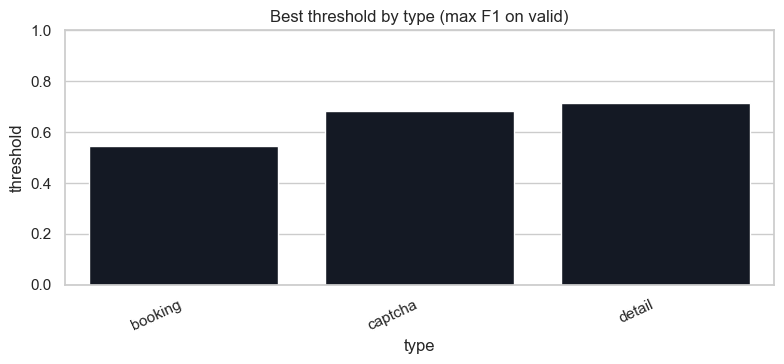

In [134]:
if len(th_by_type) > 0:
    out_path = args.MODEL_SAVE_DIR / 'threshold_by_type.csv'
    th_by_type.to_csv(out_path, index=False)
    print('saved', out_path.resolve())

    plt.figure(figsize=(8, 3.8))
    sns.barplot(data=th_by_type, x='type', y='threshold', color='#111827')
    plt.title('Best threshold by type (max F1 on valid)')
    plt.ylim(0.0, 1.0)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

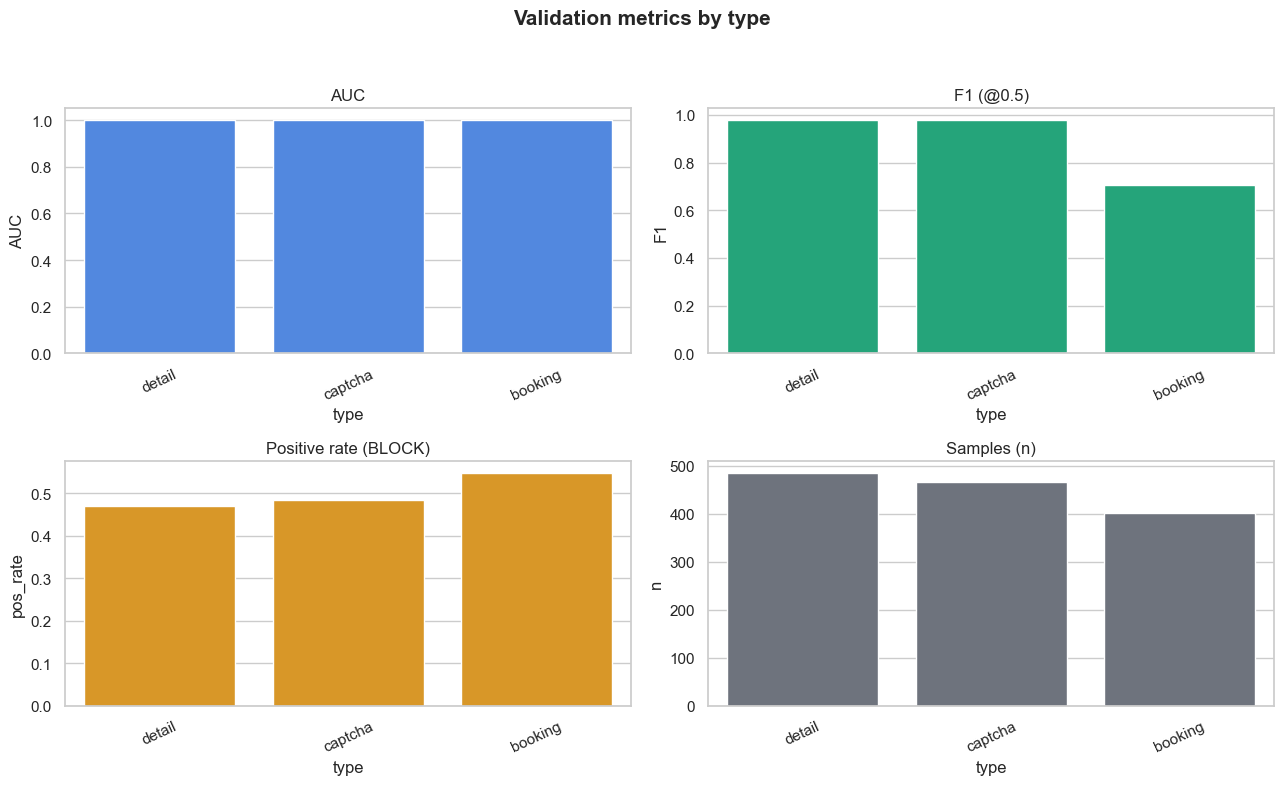

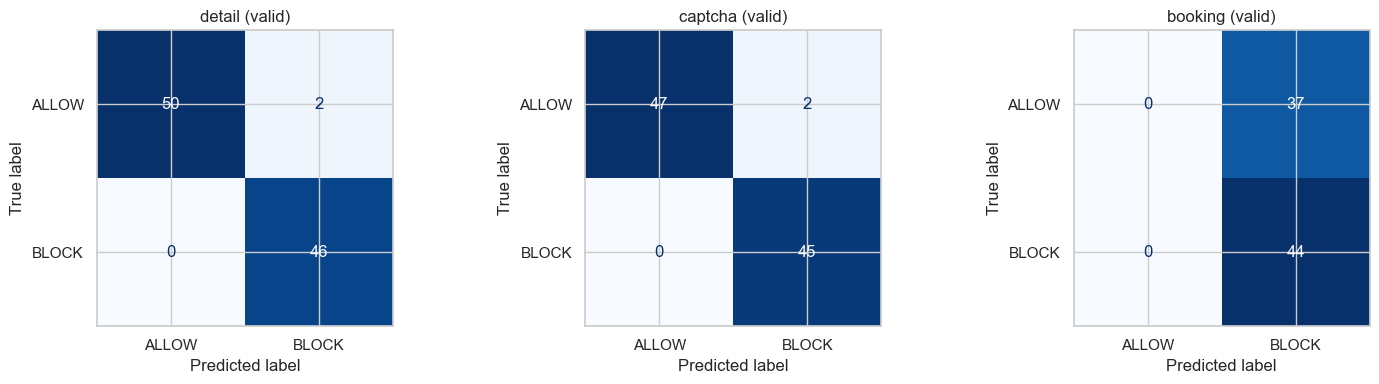

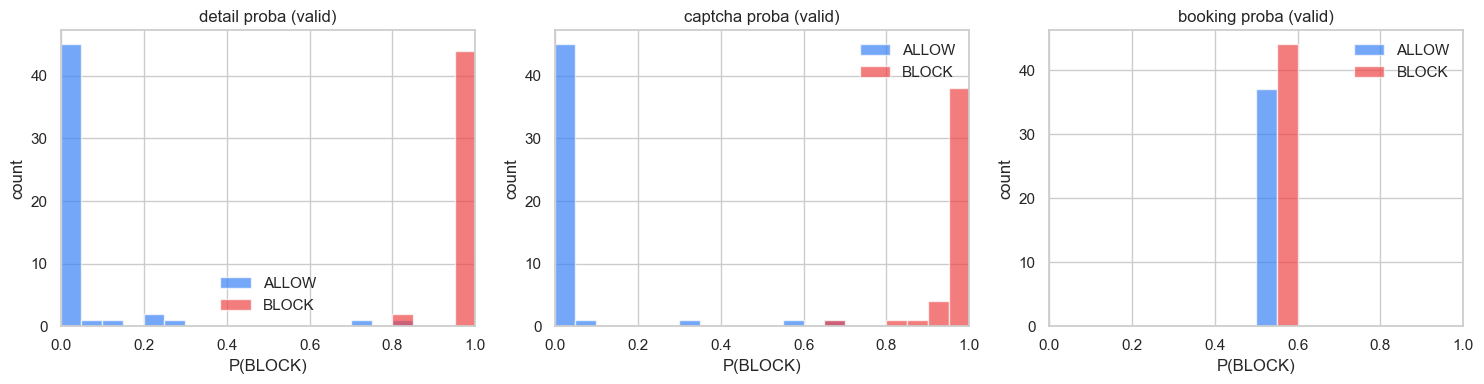

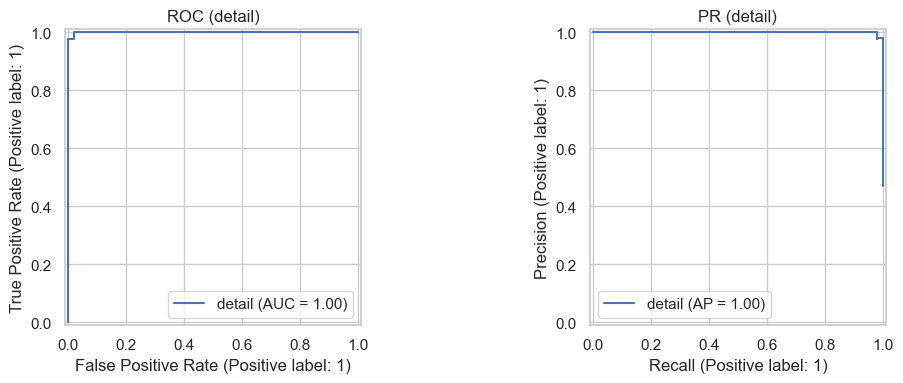

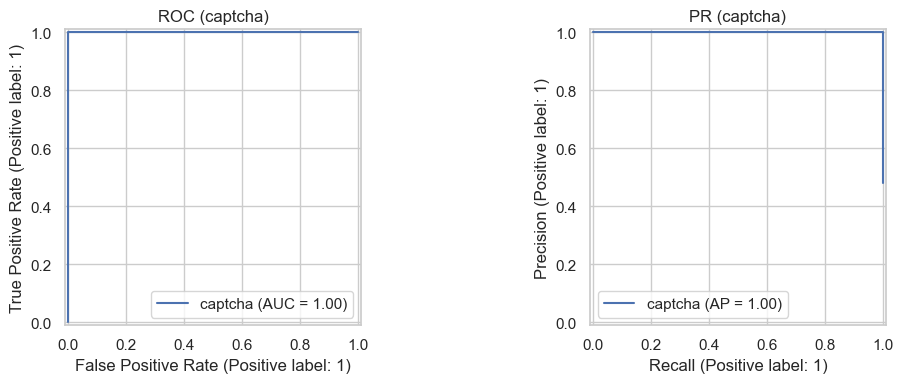

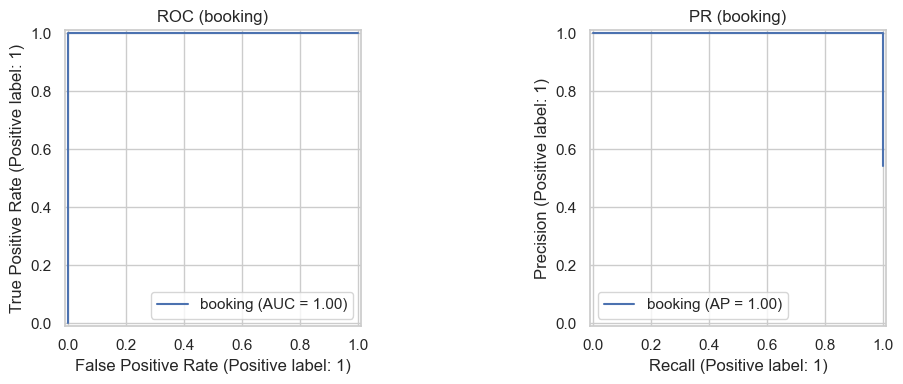

In [135]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

plots_dir = args.MODEL_SAVE_DIR / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

summary_view = summary.copy() if 'summary' in globals() else pd.DataFrame()
if len(summary_view) == 0:
    raise RuntimeError('`summary` is empty. Run training cell first.')

ok = summary_view[summary_view.get('skipped', False) == False].copy()
ok = ok.sort_values('n', ascending=False)
display_cols = [c for c in ['type','n','pos','pos_rate','n_features_used','AUC','AP','F1','Precision','Recall','LogLoss','Acc','best_iteration','elapsed_sec'] if c in ok.columns]
ok[display_cols]

# Bar summary
if len(ok) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle('Validation metrics by type', fontsize=15, fontweight='bold')

    sns.barplot(data=ok, x='type', y='AUC', ax=axes[0,0], color='#3B82F6')
    axes[0,0].set_title('AUC')
    axes[0,0].tick_params(axis='x', rotation=25)

    sns.barplot(data=ok, x='type', y='F1', ax=axes[0,1], color='#10B981')
    axes[0,1].set_title('F1 (@0.5)')
    axes[0,1].tick_params(axis='x', rotation=25)

    sns.barplot(data=ok, x='type', y='pos_rate', ax=axes[1,0], color='#F59E0B')
    axes[1,0].set_title('Positive rate (BLOCK)')
    axes[1,0].tick_params(axis='x', rotation=25)

    sns.barplot(data=ok, x='type', y='n', ax=axes[1,1], color='#6B7280')
    axes[1,1].set_title('Samples (n)')
    axes[1,1].tick_params(axis='x', rotation=25)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    fig.savefig(plots_dir / 'summary_by_type.png', dpi=160, bbox_inches='tight')
    plt.show()

# Per-type confusion matrices in one figure
    types_ok = ok['type'].tolist()
    n_types = len(types_ok)
    fig_cm, axes_cm = plt.subplots(1, n_types, figsize=(5*n_types, 4))
    if n_types == 1:
        axes_cm = [axes_cm]
    for ax, t in zip(axes_cm, types_ok):
        r = next(rr for rr in results if rr['type'] == t)
        ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['ALLOW','BLOCK']).plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(f'{t} (valid)')
    fig_cm.tight_layout()
    fig_cm.savefig(plots_dir / 'confusion_matrices_by_type.png', dpi=160, bbox_inches='tight')
    plt.show()

# Score histograms per type
    fig_h, axes_h = plt.subplots(1, n_types, figsize=(5*n_types, 4))
    if n_types == 1:
        axes_h = [axes_h]
    bins = np.linspace(0.0, 1.0, 21)
    for ax, t in zip(axes_h, types_ok):
        r = next(rr for rr in results if rr['type'] == t)
        vp = r['valid_pred']
        ax.hist(vp.loc[vp['y_true']==0, 'proba'].values, bins=bins, alpha=0.7, label='ALLOW', color='#3B82F6', edgecolor='white')
        ax.hist(vp.loc[vp['y_true']==1, 'proba'].values, bins=bins, alpha=0.7, label='BLOCK', color='#EF4444', edgecolor='white')
        ax.set_title(f'{t} proba (valid)')
        ax.set_xlabel('P(BLOCK)')
        ax.set_ylabel('count')
        ax.set_xlim(0.0, 1.0)
        ax.legend(frameon=False)
    fig_h.tight_layout()
    fig_h.savefig(plots_dir / 'score_hist_by_type.png', dpi=160, bbox_inches='tight')
    plt.show()

# ROC/PR per type (separate files)
    for t in types_ok:
        r = next(rr for rr in results if rr['type'] == t)
        vp = r['valid_pred']
        y_true = vp['y_true'].values
        y_score = vp['proba'].values
        if len(set(y_true.tolist())) < 2:
            continue
        fig_rp, axes = plt.subplots(1, 2, figsize=(11, 4))
        RocCurveDisplay.from_predictions(y_true, y_score, ax=axes[0], name=t)
        axes[0].set_title(f'ROC ({t})')
        PrecisionRecallDisplay.from_predictions(y_true, y_score, ax=axes[1], name=t)
        axes[1].set_title(f'PR ({t})')
        fig_rp.tight_layout()
        fig_rp.savefig(plots_dir / f'roc_pr_by_type_{t}.png', dpi=160, bbox_inches='tight')
        plt.show()
